In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

## Data Preprocessing

## Training Data 

In [26]:
training_set= tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 70295 files belonging to 38 classes.


### Validation Data

In [27]:
validation_set= tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [28]:
for x,y in training_set:
    print (x, x.shape)
    print (y, y.shape)
    break

tf.Tensor(
[[[[213.25 205.25 218.25]
   [217.25 209.25 222.25]
   [217.   209.   222.  ]
   ...
   [192.   186.   198.  ]
   [201.75 195.75 207.75]
   [210.   204.   216.  ]]

  [[208.   200.   213.  ]
   [209.25 201.25 214.25]
   [218.25 210.25 223.25]
   ...
   [211.25 205.25 217.25]
   [216.5  210.5  222.5 ]
   [211.5  205.5  217.5 ]]

  [[205.   197.   210.  ]
   [204.25 196.25 209.25]
   [213.75 205.75 218.75]
   ...
   [201.75 195.75 207.75]
   [222.   216.   228.  ]
   [199.75 193.75 205.75]]

  ...

  [[126.   118.   133.  ]
   [104.5   96.5  111.5 ]
   [116.75 108.75 123.75]
   ...
   [132.25 124.25 145.25]
   [128.   120.   141.  ]
   [121.   113.   134.  ]]

  [[130.5  122.5  137.5 ]
   [123.5  115.5  130.5 ]
   [114.5  106.5  121.5 ]
   ...
   [124.75 116.75 137.75]
   [121.5  113.5  134.5 ]
   [123.75 115.75 136.75]]

  [[113.75 105.75 120.75]
   [123.5  115.5  130.5 ]
   [116.5  108.5  123.5 ]
   ...
   [130.5  122.5  143.5 ]
   [122.75 114.75 135.75]
   [132.25 124.25 14

## Model Building

### To avoid overshooting:
1.decrease learning rate,default is 0.001 we are using 0.0001
2.increasing no. of neurons to avoid underfitting, add more convolution layer to extract more feature.

In [44]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [45]:
model = Sequential()

### Building Convolution Layer


In [46]:
model.add(Conv2D(filters = 32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters = 32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [47]:
model.add(Conv2D(filters = 62,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters = 62,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [48]:
model.add(Conv2D(filters = 128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters = 128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [49]:
model.add(Conv2D(filters = 256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters = 256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [50]:
model.add(Conv2D(filters = 512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters = 512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [51]:
model.add(Dropout(0.25)) #to avoid overfitting

In [52]:
model.add(Flatten())

In [53]:
model.add(Dense(units=1500,activation='relu'))

In [54]:
model.add(Dropout(0.4))

In [55]:
# Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model

In [56]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [57]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_17 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_18 (Conv2D)          (None, 63, 63, 62)        17918     
                                                                 
 conv2d_19 (Conv2D)          (None, 61, 61, 62)        34658     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 30, 30, 62)       0         
 2D)                                                  

## Training the Model

In [58]:
training_history = model.fit(x=training_set,validation_data = validation_set,epochs=10)

Epoch 1/10
2197/2197 [==============================] - 223s 100ms/step - loss: 1.3058 - accuracy: 0.6124 - val_loss: 0.5465 - val_accuracy: 0.8293
Epoch 2/10
2197/2197 [==============================] - 200s 91ms/step - loss: 0.4421 - accuracy: 0.8604 - val_loss: 0.2862 - val_accuracy: 0.9106
Epoch 3/10
2197/2197 [==============================] - 195s 89ms/step - loss: 0.2623 - accuracy: 0.9147 - val_loss: 0.2047 - val_accuracy: 0.9361
Epoch 4/10
2197/2197 [==============================] - 195s 89ms/step - loss: 0.1797 - accuracy: 0.9421 - val_loss: 0.1567 - val_accuracy: 0.9502
Epoch 5/10
2197/2197 [==============================] - 196s 89ms/step - loss: 0.1389 - accuracy: 0.9548 - val_loss: 0.1360 - val_accuracy: 0.9569
Epoch 6/10
2197/2197 [==============================] - 196s 89ms/step - loss: 0.1089 - accuracy: 0.9648 - val_loss: 0.1450 - val_accuracy: 0.9544
Epoch 7/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.0894 - accuracy: 0.9703 - val_loss: 

### Model Evaluation

In [61]:
#model evaluation on training_set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 [==============================] - 88s 40ms/step - loss: 0.0504 - accuracy: 0.9833


In [62]:
print(train_loss,train_acc)

0.050378791987895966 0.9832847118377686


In [63]:
#model evaluation on validation_set
val_loss,val_acc = model.evaluate(validation_set)

550/550 [==============================] - 32s 57ms/step - loss: 0.1492 - accuracy: 0.9555


In [64]:
print(val_loss,val_acc)

0.14921829104423523 0.9554973840713501


### Saving the model

In [66]:
model.save("trained_model.keras")

In [68]:
training_history.history

{'loss': [1.3057539463043213,
  0.44209253787994385,
  0.26231032609939575,
  0.17971180379390717,
  0.13885535299777985,
  0.10888908058404922,
  0.08937503397464752,
  0.0716550350189209,
  0.06551989912986755,
  0.05566255748271942],
 'accuracy': [0.6123622059822083,
  0.8603741526603699,
  0.9146881103515625,
  0.9420726895332336,
  0.9548189640045166,
  0.964762806892395,
  0.9702823758125305,
  0.9767266511917114,
  0.978888988494873,
  0.9820897579193115],
 'val_loss': [0.5464521050453186,
  0.28618550300598145,
  0.2046990841627121,
  0.1566735804080963,
  0.13599753379821777,
  0.1450231820344925,
  0.15298645198345184,
  0.15220285952091217,
  0.11073169112205505,
  0.14921832084655762],
 'val_accuracy': [0.8292738199234009,
  0.9105964303016663,
  0.9361484050750732,
  0.9502048492431641,
  0.9568631649017334,
  0.9544160962104797,
  0.9558388590812683,
  0.9544160962104797,
  0.9687002301216125,
  0.9554973840713501]}

In [69]:
#Recording History in json
import json
with open("training_hist.json" , "w") as f:
    json.dump(training_history.history,f)

## Accuracy Visualization

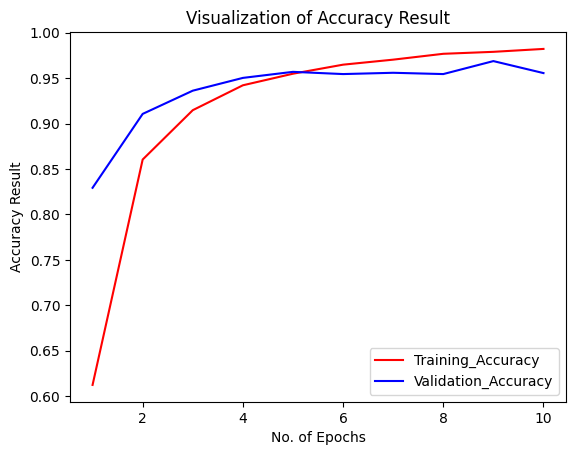

In [75]:
epochs = [i for i in range (1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training_Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation_Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()


  #### Evaluation of the model

In [79]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [80]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [82]:
y_pred = model.predict(test_set)
y_pred.shape

550/550 [==============================] - 21s 38ms/step


(17572, 38)

In [83]:
y_pred

array([[1.0000000e+00, 5.4101577e-11, 4.7467851e-13, ..., 1.7701073e-17,
        1.4155025e-15, 2.3796273e-14],
       [9.9999952e-01, 4.3132616e-11, 4.5644228e-13, ..., 1.9670727e-17,
        5.9918518e-16, 1.9861436e-15],
       [1.0000000e+00, 7.1609545e-11, 1.4862542e-12, ..., 2.8919585e-18,
        2.0650362e-14, 1.4403587e-13],
       ...,
       [2.2361429e-11, 2.7830517e-15, 4.1724811e-11, ..., 1.6150830e-13,
        6.6660436e-14, 1.0000000e+00],
       [7.2804930e-12, 9.8996457e-16, 9.2815530e-12, ..., 6.6186734e-14,
        3.2920227e-14, 1.0000000e+00],
       [3.8945409e-14, 6.8258587e-17, 3.2620065e-15, ..., 2.4987866e-16,
        1.1665263e-14, 1.0000000e+00]], dtype=float32)

In [84]:
predicted_categories = tf.argmax(y_pred,axis = 1)

In [85]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [86]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [87]:
y_true =  tf.argmax(true_categories,axis = 1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [91]:
from sklearn.metrics import classification_report,confusion_matrix

In [90]:
print(classification_report(y_true,predicted_categories,target_names = class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.96      0.96       504
                                 Apple___Black_rot       0.99      1.00      0.99       497
                          Apple___Cedar_apple_rust       0.99      0.95      0.97       440
                                   Apple___healthy       0.90      0.98      0.94       502
                               Blueberry___healthy       0.92      0.98      0.95       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.96      0.97       421
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.95      0.95       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.97      0.

In [95]:
cm = confusion_matrix(y_true,predicted_categories)
print(cm)
cm.shape

[[486   2   0 ...   0   0   0]
 [  0 495   0 ...   0   0   0]
 [  0   0 417 ...   0   0   1]
 ...
 [  0   0   0 ... 482   0   0]
 [  0   0   0 ...   0 441   0]
 [  0   0   0 ...   0   0 476]]


(38, 38)

 #### Confusion Matrix Visualization

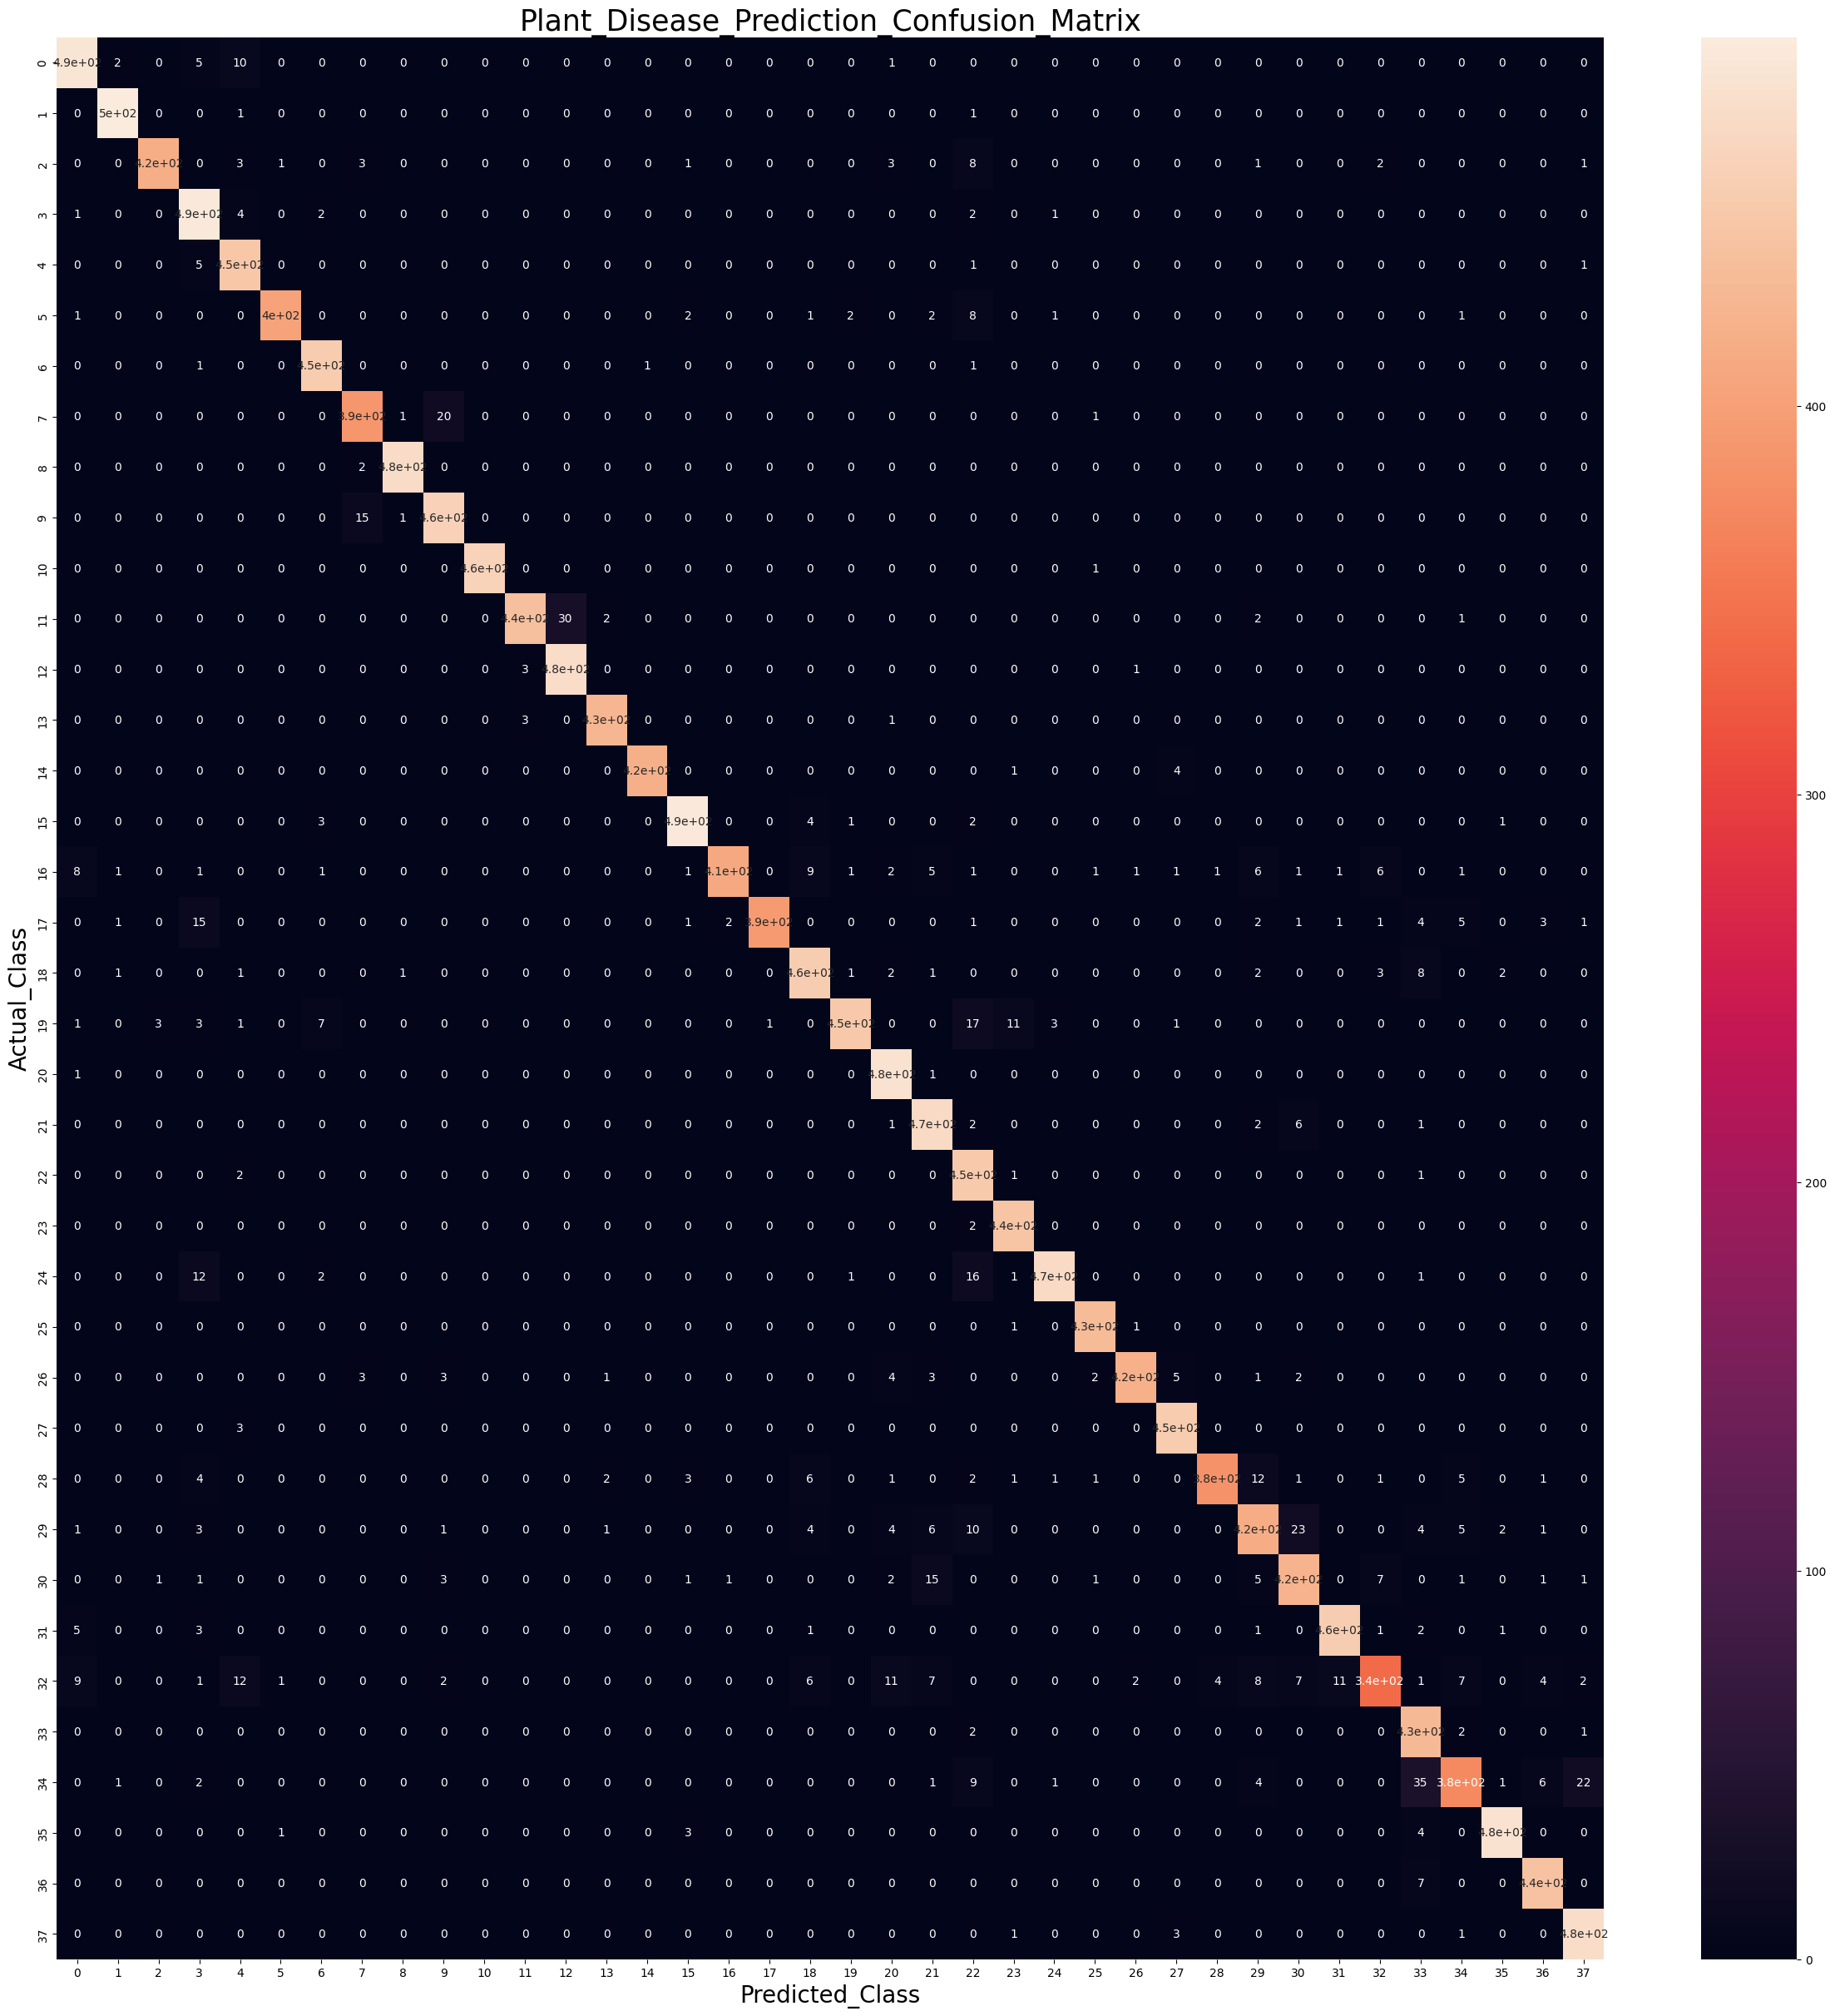

In [104]:
plt.figure(figsize=(30,30))
sns.heatmap(cm,annot = True,annot_kws=({'size':10}))
plt.xlabel("Predicted_Class",fontsize=20)
plt.ylabel("Actual_Class",fontsize=20)
plt.title("Plant_Disease_Prediction_Confusion_Matrix",fontsize=25)
plt.show()